# Exploración de Capacitaciones — PISST
**Objetivo:** Explorar asistencias y evaluaciones para validar la lógica de `analizar_capacitaciones()`.

Este notebook es de solo lectura — nunca escribe en la BD.

## 1. Configuración e imports

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

sys.path.insert(0, os.path.abspath('..'))
load_dotenv('../.env')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Pandas:', pd.__version__, '| NumPy:', np.__version__)

Pandas: 3.0.3 | NumPy: 2.4.6


## 2. Conexión a la BD

In [2]:
DATABASE_URL = os.getenv("DATABASE_URL")

# Filtrar por empresa — cambiar este UUID según la empresa a analizar
EMPRESA_ID = os.getenv("EMPRESA_ID", None)  # None = leer todas (solo para desarrollo)

if EMPRESA_ID:
    print("Filtrando por empresa:", EMPRESA_ID)
else:
    print("[ADVERTENCIA] Sin filtro de empresa — se muestran datos de TODOS los clientes")

engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM capacitaciones"))
    print(f"Total capacitaciones en BD: {result.scalar()}")


Filtrando por empresa: eae57674-a3fd-420f-b3c4-0800d98a0f93
Total capacitaciones en BD: 9


## 3. Carga de datos (Ingesta)

In [3]:
params = {}
filtro_c = ""
filtro_c_and = ""
if EMPRESA_ID:
    filtro_c     = "WHERE c.empresa_id = :empresa_id"
    filtro_c_and = "AND c.empresa_id = :empresa_id"
    params["empresa_id"] = EMPRESA_ID

query_asistencias = text(f"""
SELECT
    a.empleado_id,
    u.nombre         AS empleado_nombre,
    a.estado         AS asistencia_estado,
    sc.estado        AS sesion_estado,
    c.empresa_id
FROM asistencias a
JOIN sesiones_capacitacion sc ON sc.id = a.sesion_id
JOIN capacitaciones c         ON c.id  = sc.capacitacion_id
JOIN users u                  ON u.id  = a.empleado_id
{filtro_c}
""")

query_evaluaciones = text(f"""
SELECT
    re.empleado_id,
    re.aprobado,
    re.puntaje_final,
    c.empresa_id
FROM respuestas_empleado re
JOIN evaluaciones ev          ON ev.id  = re.evaluacion_id
JOIN sesiones_capacitacion sc ON sc.id  = ev.sesion_id
JOIN capacitaciones c         ON c.id   = sc.capacitacion_id
{filtro_c}
""")

query_sin_sesion = text(f"""
SELECT c.id, c.titulo, c.empresa_id
FROM capacitaciones c
WHERE c.activo = TRUE
  AND NOT EXISTS (
    SELECT 1 FROM sesiones_capacitacion sc
    WHERE sc.capacitacion_id = c.id AND sc.estado = 'realizada'
  )
  {filtro_c_and}
""")

df_asistencias  = pd.read_sql(query_asistencias,  engine, params=params or None)
df_evaluaciones = pd.read_sql(query_evaluaciones, engine, params=params or None)
df_sin_sesion   = pd.read_sql(query_sin_sesion,   engine, params=params or None)

print(f"Asistencias: {len(df_asistencias)} | Evaluaciones: {len(df_evaluaciones)} | Cap sin sesion realizada: {len(df_sin_sesion)}")
df_asistencias.head()


Asistencias: 23 | Evaluaciones: 6 | Cap sin sesion realizada: 2


,empleado_id,empleado_nombre,asistencia_estado,sesion_estado,empresa_id
0,97c206b5-a6c5-4f75-acf7-6a9224c23ef5,luis carlos galán,ausente,programada,eae57674-a3fd-420f-b3c4-0800d98a0f93
1,a0430a41-6e73-44d3-ae9f-cb24796389e5,Pedro Empleado Demo,ausente,programada,eae57674-a3fd-420f-b3c4-0800d98a0f93
2,57a86591-3227-4ad9-9d95-ae1cc78d0827,María Gerencia Demo,presente,programada,eae57674-a3fd-420f-b3c4-0800d98a0f93
3,a0430a41-6e73-44d3-ae9f-cb24796389e5,Pedro Empleado Demo,presente,programada,eae57674-a3fd-420f-b3c4-0800d98a0f93
4,35f0a5e4-8e83-4e08-8201-57cdf00d4b18,Santiago,ausente,programada,eae57674-a3fd-420f-b3c4-0800d98a0f93


## 4. Inspección estructural

In [4]:
print('Shape asistencias:', df_asistencias.shape)
df_asistencias.info()
print()
print('Estados de asistencia:', df_asistencias['asistencia_estado'].unique())
print('Estados de sesión:', df_asistencias['sesion_estado'].unique())

Shape asistencias: (23, 5)
<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   empleado_id        23 non-null     object
 1   empleado_nombre    23 non-null     str   
 2   asistencia_estado  23 non-null     str   
 3   sesion_estado      23 non-null     str   
 4   empresa_id         23 non-null     object
dtypes: object(2), str(3)
memory usage: 1.0+ KB

Estados de asistencia: <StringArray>
['ausente', 'presente', 'justificado']
Length: 3, dtype: str
Estados de sesión: <StringArray>
['programada', 'realizada']
Length: 2, dtype: str


## 5. Análisis descriptivo

In [5]:
print('Distribución de asistencia:')
print(df_asistencias['asistencia_estado'].value_counts())
print()

if len(df_evaluaciones) > 0:
    print('Distribución aprobado/reprobado:')
    print(df_evaluaciones['aprobado'].value_counts())
    print()
    print('Estadísticas de puntaje:')
    print(df_evaluaciones['puntaje_final'].describe())

Distribución de asistencia:
asistencia_estado
presente       17
ausente         5
justificado     1
Name: count, dtype: int64

Distribución aprobado/reprobado:
aprobado
True    6
Name: count, dtype: int64

Estadísticas de puntaje:
count     6.00
mean    100.00
std       0.00
min     100.00
25%     100.00
50%     100.00
75%     100.00
max     100.00
Name: puntaje_final, dtype: float64


## 5b. Visualizaciones

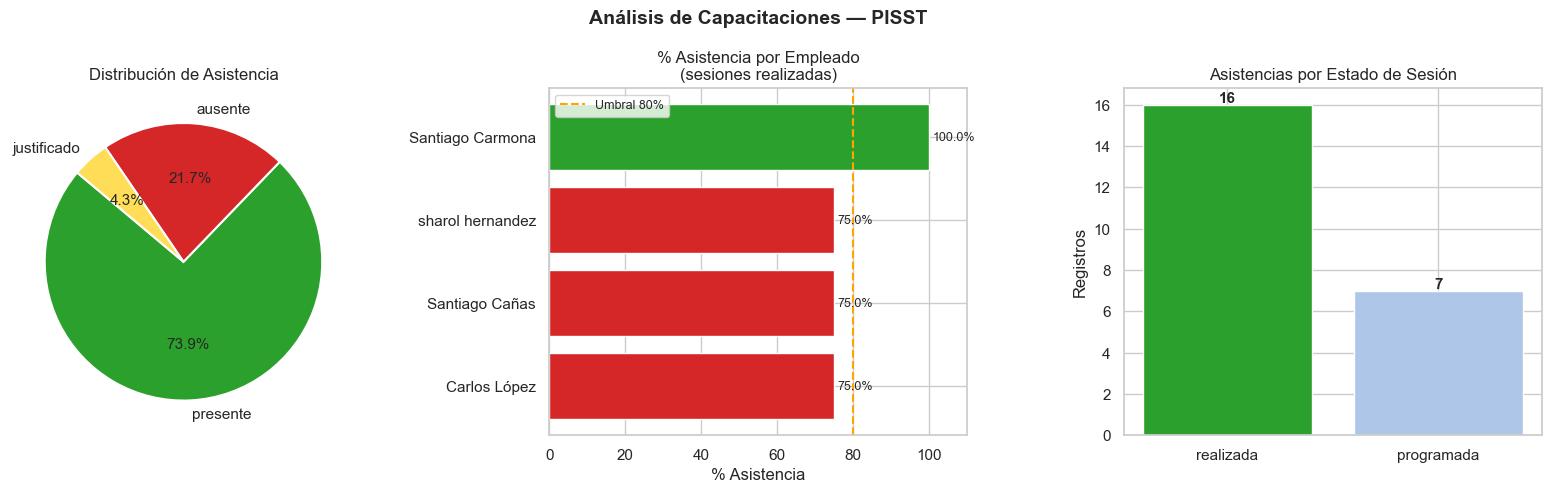

Gráfica guardada en data/processed/capacitaciones_graficas.png


In [6]:
if len(df_asistencias) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Análisis de Capacitaciones — PISST', fontsize=14, fontweight='bold')

    # --- Gráfica 1: Distribución de asistencia general ---
    asi_counts = df_asistencias['asistencia_estado'].value_counts()
    colores_asi = {'presente': '#2ca02c', 'ausente': '#d62728', 'justificado': '#ffdd57'}
    c = [colores_asi.get(e, '#999') for e in asi_counts.index]
    axes[0].pie(
        asi_counts.values,
        labels=asi_counts.index,
        colors=c,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    axes[0].set_title('Distribución de Asistencia')

    # --- Gráfica 2: % asistencia por empleado (sesiones realizadas) ---
    df_reali = df_asistencias[df_asistencias['sesion_estado'] == 'realizada'].copy()
    if len(df_reali) > 0:
        df_reali['presente'] = np.where(df_reali['asistencia_estado'] == 'presente', 1, 0)
        por_emp = df_reali.groupby('empleado_nombre')['presente'].agg(['sum', 'count']).reset_index()
        por_emp['pct'] = np.round(por_emp['sum'] / por_emp['count'] * 100, 1)
        por_emp = por_emp.sort_values('pct')

        colores_barra = ['#d62728' if p < 80 else '#2ca02c' for p in por_emp['pct']]
        axes[1].barh(por_emp['empleado_nombre'], por_emp['pct'], color=colores_barra)
        axes[1].axvline(x=80, color='orange', linestyle='--', linewidth=1.5, label='Umbral 80%')
        axes[1].set_title('% Asistencia por Empleado\n(sesiones realizadas)')
        axes[1].set_xlabel('% Asistencia')
        axes[1].set_xlim(0, 110)
        axes[1].legend(fontsize=9)
        for i, (_, row) in enumerate(por_emp.iterrows()):
            axes[1].text(row['pct'] + 1, i, f"{row['pct']}%", va='center', fontsize=9)
    else:
        axes[1].text(0.5, 0.5, 'Sin sesiones\nrealizadas',
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('% Asistencia por Empleado')

    # --- Gráfica 3: Estado de sesiones ---
    ses_counts = df_asistencias['sesion_estado'].value_counts()
    colores_ses = {'realizada': '#2ca02c', 'programada': '#aec7e8',
                   'no_realizada': '#d62728', 'cancelada': '#999'}
    c3 = [colores_ses.get(e, '#999') for e in ses_counts.index]
    axes[2].bar(ses_counts.index, ses_counts.values, color=c3, edgecolor='white')
    axes[2].set_title('Asistencias por Estado de Sesión')
    axes[2].set_ylabel('Registros')
    for i, v in enumerate(ses_counts.values):
        axes[2].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    os.makedirs('../data/processed', exist_ok=True)
    plt.savefig('../data/processed/capacitaciones_graficas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada en data/processed/capacitaciones_graficas.png')
else:
    print('Sin datos para graficar.')

## 6. Transformaciones y cálculos (lógica del servicio)

In [7]:
# --- Tasa de aprobación ---
if len(df_evaluaciones) == 0:
    total_evaluaciones = 0
    tasa_aprobacion = 0.0
else:
    total_evaluaciones = len(df_evaluaciones)
    tasa_aprobacion = round(df_evaluaciones['aprobado'].mean() * 100, 1)

print(f'Total evaluaciones: {total_evaluaciones}')
print(f'Tasa de aprobación: {tasa_aprobacion}%')

Total evaluaciones: 6
Tasa de aprobación: 100.0%


In [8]:
# --- Asistencia promedio y alertas con NumPy ---
if len(df_asistencias) == 0:
    asistencia_promedio = 0.0
    alertas = []
else:
    # Solo contar sesiones de capacitaciones que ya se realizaron
    df_realizadas = df_asistencias[df_asistencias['sesion_estado'] == 'realizada']

    if len(df_realizadas) == 0:
        asistencia_promedio = 0.0
        alertas = []
    else:
        # % asistencia por empleado (presente = 1, ausente/justificado = 0)
        df_realizadas = df_realizadas.copy()
        df_realizadas['presente'] = np.where(df_realizadas['asistencia_estado'] == 'presente', 1, 0)

        por_empleado = df_realizadas.groupby(['empleado_id', 'empleado_nombre'])['presente'].agg(['sum', 'count'])
        por_empleado['pct_asistencia'] = round(por_empleado['sum'] / por_empleado['count'] * 100, 1)
        por_empleado = por_empleado.reset_index()

        asistencia_promedio = round(por_empleado['pct_asistencia'].mean(), 1)

        # Alertas: empleados con asistencia < 80%
        df_alertas = por_empleado[por_empleado['pct_asistencia'] < 80]
        alertas = df_alertas[['empleado_id', 'empleado_nombre', 'pct_asistencia']].rename(
            columns={'empleado_nombre': 'nombre', 'pct_asistencia': 'asistencia_pct'}
        ).to_dict('records')

        print('Por empleado (asistencia):')
        print(por_empleado[['empleado_nombre', 'pct_asistencia']].to_string(index=False))

print(f'\nAsistencia promedio: {asistencia_promedio}%')
print(f'Alertas (< 80%): {len(alertas)}')

Por empleado (asistencia):
 empleado_nombre  pct_asistencia
  Santiago Cañas           75.00
Santiago Carmona          100.00
    Carlos López           75.00
sharol hernandez           75.00

Asistencia promedio: 81.2%
Alertas (< 80%): 3


In [9]:
# Resultado final
resultado = {
    'total_evaluaciones': total_evaluaciones,
    'tasa_aprobacion_pct': tasa_aprobacion,
    'asistencia_promedio_pct': asistencia_promedio,
    'alertas_asistencia': alertas,
    'capacitaciones_sin_sesion_realizada': len(df_sin_sesion),
}

import json
print(json.dumps(resultado, indent=2, ensure_ascii=False, default=str))

{
  "total_evaluaciones": 6,
  "tasa_aprobacion_pct": 100.0,
  "asistencia_promedio_pct": 81.2,
  "alertas_asistencia": [
    {
      "empleado_id": "187d2d0e-5e0b-4653-b0ff-f2856f663382",
      "nombre": "Santiago Cañas",
      "asistencia_pct": 75.0
    },
    {
      "empleado_id": "4ba76e4e-4e01-43c1-b325-1c2f1445dc5c",
      "nombre": "Carlos López",
      "asistencia_pct": 75.0
    },
    {
      "empleado_id": "ae5951c0-d832-487f-a5a7-c9f12c6b2bc4",
      "nombre": "sharol hernandez",
      "asistencia_pct": 75.0
    }
  ],
  "capacitaciones_sin_sesion_realizada": 2
}


## 7. Exportación de hallazgos

In [10]:
os.makedirs('../data/processed', exist_ok=True)

if len(df_asistencias) > 0:
    df_asistencias.to_csv('../data/processed/asistencias_exploradas.csv', index=False)
if len(df_evaluaciones) > 0:
    df_evaluaciones.to_csv('../data/processed/evaluaciones_exploradas.csv', index=False)
print('Exportado a data/processed/')

Exportado a data/processed/


## 8. Conclusiones para el servicio

- `analizar_capacitaciones()` necesita 3 queries: asistencias, evaluaciones, capacitaciones sin sesión realizada
- Usar `np.where` para convertir estado → 1/0 antes de calcular el promedio por empleado
- Las alertas de asistencia solo se generan sobre sesiones con `estado == 'realizada'`
- La tasa de aprobación es `aprobado.mean() * 100` sobre todas las respuestas del empleado
- El umbral de alerta es `< 80%` de asistencia